# Combinatorial Library Generation of Distamycin Analogues

This notebook rebuilds the Boger distamycin analogue library used in the QSAR analysis. The library contains 2,640 structures divided into two sets of 1,320 trimer structures. One set is BOC-capped and the other is DMABA-capped.

The enumeration uses 20 A-position subunits consisting of 10 scaffolds with either a BOC or DMABA N-terminal cap, 11 B-position subunits and 12 C-position subunits. This gives 2,640 structures in total, and the generated library is saved as `cleandata.csv`.

Experimental IC₅₀ values are matched to the enumerated structures using canonical SMILES. Additional compounds from the literature are manually added. Duplicate structures are removed and the final modelling dataset is saved as `processed_data.csv`.

In [1]:
from pathlib import Path

def find_project_root(markers=("requirements.txt", ".git", "README.md")):
    here = Path.cwd().resolve()
    for parent in (here, *here.parents):
        if any((parent / m).exists() for m in markers):
            return parent
    raise RuntimeError(f"No project-root marker {markers} found above {here}")

PROJECT_ROOT = find_project_root()

DATA_RAW  = PROJECT_ROOT / "data" / "raw"
DATA_PROC = PROJECT_ROOT / "data" / "processed"

DATA_PROC.mkdir(parents=True, exist_ok=True)

RAW_FILES = {
    "fragments": DATA_RAW / "data.csv",
    "boger_ic50": DATA_RAW / "boger_ic50.csv",
    "manual_additions": DATA_RAW / "manual_additions.csv",
}

for label, path in RAW_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required input file for {label}: {path}")

## 1. Imports and paths

In [2]:
import sys
import platform

import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw
import rdkit

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("RDKit:", rdkit.__version__)
print("pandas:", pd.__version__)

def canon(smiles):
    m = Chem.MolFromSmiles(str(smiles))
    return Chem.MolToSmiles(m, canonical=True) if m is not None else None

Python: 3.13.6
Platform: macOS-26.5.2-arm64-arm-64bit-Mach-O
RDKit: 2025.09.1
pandas: 2.3.2


## 2. Fragment loading and validation

Fragment SMILES were taken from the subunit definitions reported by Boger et al. A fragments contain one dummy atom, B fragments contain two, and C fragments contain one.

The A position contains 20 subunits consisting of 10 heteroaromatic scaffolds, each in BOC- and DMABA-capped forms. The B position contains 11 subunits and the C position contains 12.

In [3]:
fragments_df = pd.read_csv(RAW_FILES["fragments"])

required_fragment_cols = {"ID", "TYPE", "SMILES"}
missing_cols = required_fragment_cols - set(fragments_df.columns)
assert not missing_cols, f"Missing columns in data.csv: {missing_cols}"

fragments_df = fragments_df[["ID", "TYPE", "SMILES"]].copy()

A_df = fragments_df[fragments_df["ID"] == "A"].copy().reset_index(drop=True)
B_df = fragments_df[fragments_df["ID"] == "B"].copy().reset_index(drop=True)
C_df = fragments_df[fragments_df["ID"] == "C"].copy().reset_index(drop=True)

print(f"A fragments: {len(A_df)}")
print(f"B fragments: {len(B_df)}")
print(f"C fragments: {len(C_df)}")
expected_n = len(A_df) * len(B_df) * len(C_df)
print(f"Expected enumerated structures: {expected_n}")

assert len(A_df) == 20, f"A fragments: expected 20, got {len(A_df)}, check data/raw/data.csv"
assert len(B_df) == 11, f"B fragments: expected 11, got {len(B_df)}, check data/raw/data.csv"
assert len(C_df) == 12, f"C fragments: expected 12, got {len(C_df)}, check data/raw/data.csv"
assert len(A_df) * len(B_df) * len(C_df) == 2640

A fragments: 20
B fragments: 11
C fragments: 12
Expected enumerated structures: 2640


### 2.1 Fragment SMILES validation

In [4]:
def validate_smiles(df, label):
    invalid = []
    for i, row in df.iterrows():
        mol = Chem.MolFromSmiles(row["SMILES"])
        if mol is None:
            invalid.append((i, row["SMILES"]))
    if invalid:
        print(f"{label}: {len(invalid)} invalid SMILES found:")
        for idx, smi in invalid:
            print(f"  Row {idx}: {smi}")
    else:
        print(f"{label}: all SMILES valid")
    return invalid

assert not validate_smiles(A_df, "A fragments")
assert not validate_smiles(B_df, "B fragments")
assert not validate_smiles(C_df, "C fragments")

A fragments: all SMILES valid
B fragments: all SMILES valid
C fragments: all SMILES valid


### 2.2 Fragment visualisation

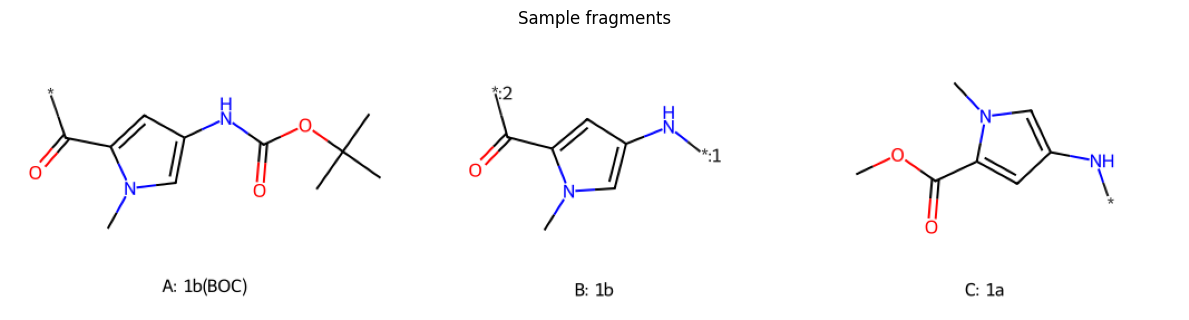

In [5]:
example_mols = []
example_labels = []

for label, frag_df in [("A", A_df), ("B", B_df), ("C", C_df)]:
    mol = Chem.MolFromSmiles(frag_df.iloc[0]["SMILES"])
    if mol:
        example_mols.append(mol)
        example_labels.append(f"{label}: {frag_df.iloc[0]['TYPE']}")

img = Draw.MolsToGridImage(example_mols, molsPerRow=3, subImgSize=(350, 250),
                            legends=example_labels, returnPNG=False)
plt.figure(figsize=(12, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Sample fragments')
plt.tight_layout()
plt.show()

## 3. A-B coupling

Each A fragment is coupled to each B fragment through the A dummy atom and the B `[*:1]` dummy atom. The second B dummy atom is retained for coupling to C.

A is coupled to B before AB is coupled to C because each B fragment contains two dummy atoms. Coupling A first leaves a single attachment site for C.

In [6]:
def bond_dummies(a_smiles, b_smiles):
    """Join A to B at the [*:1] dummy on B.

    Returns the A-B SMILES with B's [*:2] dummy kept for coupling to C,
    or None if the SMILES cannot be parsed or the expected dummy is missing.
    """
    molA = Chem.MolFromSmiles(a_smiles)
    molB = Chem.MolFromSmiles(b_smiles)

    if molA is None or molB is None:
        return None

    try:
        idx_A = next(atom.GetIdx() for atom in molA.GetAtoms()
                     if atom.GetAtomicNum() == 0)
        idx_B = next(atom.GetIdx() for atom in molB.GetAtoms()
                     if atom.GetAtomicNum() == 0 and atom.GetAtomMapNum() == 1)
    except StopIteration:
        return None

    combo = Chem.CombineMols(molA, molB)
    rw = Chem.RWMol(combo)

    offset = molA.GetNumAtoms()
    rw.AddBond(idx_A, idx_B + offset, Chem.BondType.SINGLE)

    try:
        Chem.SanitizeMol(rw)
        return Chem.MolToSmiles(rw, canonical=True)
    except Exception:
        return None

results = []
ab_errors = 0

for _, a_row in A_df.iterrows():
    for _, b_row in B_df.iterrows():
        connected_smiles = bond_dummies(a_row["SMILES"], b_row["SMILES"])
        if connected_smiles is None:
            ab_errors += 1
            continue
        combined_type = f"{a_row['TYPE']} + {b_row['TYPE']}"
        results.append({
            "A_SMILES": a_row["SMILES"],
            "B_SMILES": b_row["SMILES"],
            "AB_SMILES": connected_smiles,
            "TYPE": combined_type
        })

out_df = pd.DataFrame(results)
out_df.to_csv(DATA_PROC / "AB.csv", index=False)
print(f"A-B structures: {len(results)}")
if ab_errors > 0:
    print(f"A-B coupling errors: {ab_errors}")

A-B structures: 220


## 4. A-B-C coupling

Each A-B intermediate is then coupled to each C fragment through the remaining dummy atom on B and the dummy atom on C.

In [7]:
ab_df = pd.read_csv(DATA_PROC / "AB.csv")

C_smiles = C_df["SMILES"].tolist()
C_types  = C_df["TYPE"].tolist()

results = []
abc_errors = 0

def bond_AB_to_C(ab_smiles, c_smiles):
    """Join an A-B intermediate to C at B's remaining [*:2] dummy.

    Returns the A-B-C SMILES with the dummy atoms retained for removal later,
    or None if the SMILES cannot be parsed or the expected dummy is missing.
    """
    molAB = Chem.MolFromSmiles(ab_smiles)
    molC = Chem.MolFromSmiles(c_smiles)

    if molAB is None or molC is None:
        return None

    try:
        idx_B = next(atom.GetIdx() for atom in molAB.GetAtoms()
                     if atom.GetAtomicNum() == 0 and atom.GetAtomMapNum() == 2)
        idx_C = next(atom.GetIdx() for atom in molC.GetAtoms()
                     if atom.GetAtomicNum() == 0)
    except StopIteration:
        return None

    combo = Chem.CombineMols(molAB, molC)
    rw = Chem.RWMol(combo)

    offset = molAB.GetNumAtoms()
    rw.AddBond(idx_B, idx_C + offset, Chem.BondType.SINGLE)

    try:
        Chem.SanitizeMol(rw)
        return Chem.MolToSmiles(rw, canonical=True)
    except Exception:
        return None

for _, row in ab_df.iterrows():
    for c_smiles, c_type in zip(C_smiles, C_types):
        abc_smiles = bond_AB_to_C(row["AB_SMILES"], c_smiles)
        if abc_smiles is None:
            abc_errors += 1
            continue
        combined_type = f"{row['TYPE']} + {c_type}"
        results.append({
            "A_SMILES": row["A_SMILES"],
            "B_SMILES": row["B_SMILES"],
            "C_SMILES": c_smiles,
            "ABC_SMILES": abc_smiles,
            "TYPE": combined_type
        })

out_df = pd.DataFrame(results)
out_df.to_csv(DATA_PROC / "ABC_bonded_dummies.csv", index=False)
print(f"A-B-C structures: {len(results)}")
if abc_errors > 0:
    print(f"A-B-C coupling errors: {abc_errors}")

A-B-C structures: 2640


## 5. Dummy atom removal

Dummy atoms are removed from the coupled A-B-C intermediates from the highest index to the lowest, so that deleting one dummy atom does not change the indices of those still to be removed.

In [8]:
abc_bonded_df = pd.read_csv(DATA_PROC / "ABC_bonded_dummies.csv")

results = []
clean_errors = 0

def remove_dummies_and_bond_all(mol_smiles):
    """
    Remove dummy atoms and return a canonical SMILES.
    Returns None if parsing or sanitisation fails.
    """
    mol = Chem.MolFromSmiles(mol_smiles)
    if mol is None:
        return None

    rw = Chem.RWMol(mol)

    dummy_indices = sorted(
        [atom.GetIdx() for atom in rw.GetAtoms() if atom.GetAtomicNum() == 0],
        reverse=True
    )

    for idx in dummy_indices:
        neighbours = [nbr.GetIdx() for nbr in rw.GetAtomWithIdx(idx).GetNeighbors()]
        assert len(neighbours) == 2, f"dummy {idx} has {len(neighbours)} neighbours, expected 2"
        if rw.GetBondBetweenAtoms(neighbours[0], neighbours[1]) is None:
            rw.AddBond(neighbours[0], neighbours[1], Chem.BondType.SINGLE)
        rw.RemoveAtom(idx)

    try:
        Chem.SanitizeMol(rw)
        return Chem.MolToSmiles(rw, canonical=True)
    except Exception:
        return None

for _, row in abc_bonded_df.iterrows():
    clean_smiles = remove_dummies_and_bond_all(row["ABC_SMILES"])
    if clean_smiles is None:
        clean_errors += 1
        continue
    results.append({
        "A_SMILES": row["A_SMILES"],
        "B_SMILES": row["B_SMILES"],
        "C_SMILES": row["C_SMILES"],
        "ABC_SMILES": clean_smiles,
        "TYPE": row["TYPE"]
    })

out_df = pd.DataFrame(results)
out_df.to_csv(DATA_PROC / "ABC_clean.csv", index=False)
print(f"Cleaned A-B-C structures: {len(results)}")
if clean_errors > 0:
    print(f"Cleanup errors: {clean_errors}")

Cleaned A-B-C structures: 2640


In [9]:
def verify_join(a, b, c, prod):
    ms = [Chem.MolFromSmiles(s) for s in (a, b, c, prod)]
    if any(m is None for m in ms):
        return False
    mA, mB, mC, mP = ms
    if mP.GetNumAtoms() != mA.GetNumAtoms() + mB.GetNumAtoms() + mC.GetNumAtoms() - 4:
        return False
    return "." not in Chem.MolToSmiles(mP)

bad = [r["ABC_SMILES"] for _, r in out_df.iterrows()
       if not verify_join(r["A_SMILES"], r["B_SMILES"], r["C_SMILES"], r["ABC_SMILES"])]
print(f"Connectivity and atom count check: {len(bad)} molecules failed")
assert not bad, bad[:5]

Connectivity and atom count check: 0 molecules failed


## 6. Final dataset preparation

In [10]:
final_df = pd.read_csv(DATA_PROC / "ABC_clean.csv")

final_df['IC50'] = None
final_df = final_df.drop(columns=['A_SMILES', 'B_SMILES', 'C_SMILES'])
final_df = final_df.rename(columns={'ABC_SMILES': 'SMILES'})

final_df.to_csv(DATA_PROC / "cleandata.csv", index=False)
print(f"Saved {len(final_df)} molecules to cleandata.csv")

Saved 2640 molecules to cleandata.csv


### 6.1 Library summary

The enumeration produces 2,640 structures, which are saved in `cleandata.csv`. After experimental IC₅₀ values are matched and literature compounds are added, `processed_data.csv` contains 2,651 rows. Of these compounds, 116 have L1210 labels and are used for modelling, while the remaining 2,535 are unlabelled. These groups are defined in Section 2.1 of distamycin_sar_modelling.ipynb. Section 10.2 of that notebook shows that a Tanimoto applicability domain filter does not separate the labelled and unlabelled compounds because both groups come from the same enumeration.

In [11]:
_n_manual = len(pd.read_csv(RAW_FILES["manual_additions"]))

print(f"Enumerated Boger library structures: {len(final_df)}")
print(f"Manual additions before deduplication: {_n_manual}")
print(f"Total structures before deduplication: {len(final_df) + _n_manual}")
print(f"Unique structures by canonical SMILES: {final_df['SMILES'].map(canon).nunique()}")
print(f"Unique combinations: {final_df['TYPE'].nunique()}")

Enumerated Boger library structures: 2640
Manual additions before deduplication: 32
Total structures before deduplication: 2672
Unique structures by canonical SMILES: 2640
Unique combinations: 2640


### 6.2 Product visualisation

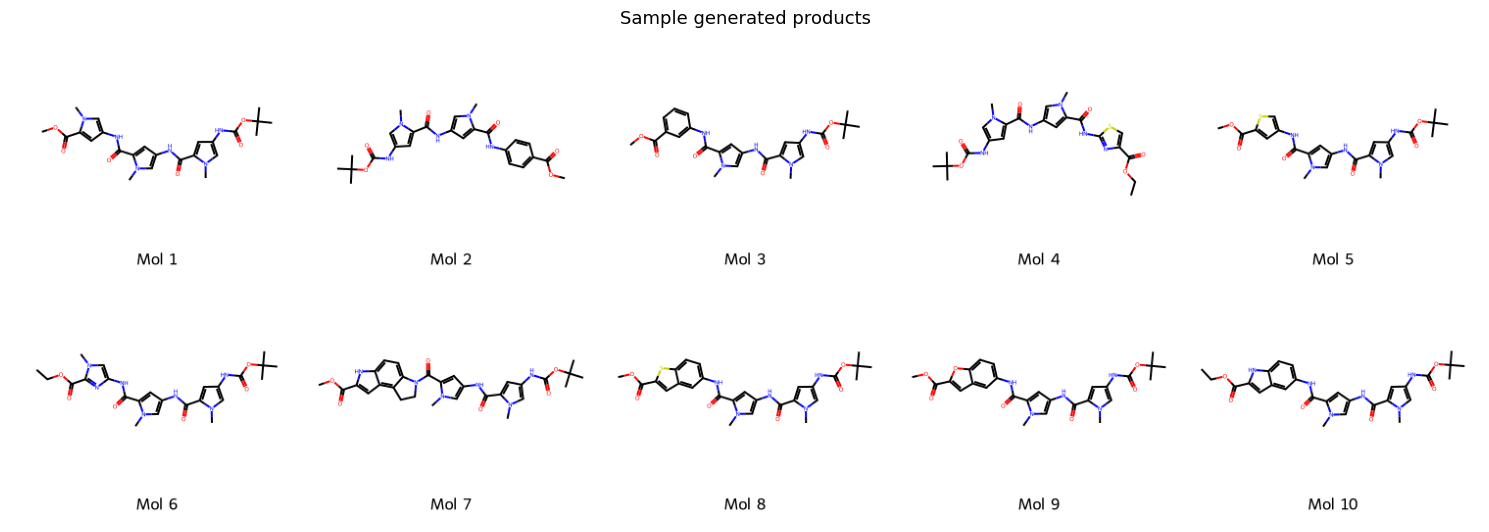

In [12]:
sample_mols = []
sample_labels = []

for i, row in final_df.head(10).iterrows():
    mol = Chem.MolFromSmiles(row["SMILES"])
    if mol:
        sample_mols.append(mol)
        sample_labels.append(f"Mol {i+1}")

img = Draw.MolsToGridImage(sample_mols, molsPerRow=5, subImgSize=(300, 250),
                            legends=sample_labels, returnPNG=False)
plt.figure(figsize=(15, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Sample generated products", fontsize=13)
plt.tight_layout()
plt.show()

### 6.3 Processed dataset generation

Experimental IC₅₀ values are stored in `boger_ic50.csv`, with censored assay limit values flagged explicitly. These values are matched to the generated structures using canonical SMILES rather than row order.

The additional literature structures added manually are stored in `manual_additions.csv`. These are combined with the enumerated library and duplicate structures are removed using canonical SMILES. The final dataset is saved as `processed_data.csv`.

Compound 128 has two different L1210 IC₅₀ values in Tables 3 and 6 of the JACS source (32 µM and 17 µM). Both tables give the same DNA binding constant of 5.6 × 10⁶ M⁻¹, suggesting that the same compound was tested in two separate cytotoxicity runs. Since there is no basis for choosing between the two values, compound 128 is kept as an unlabelled structure in the prediction set.

Duplicate structures are removed using canonical SMILES. If one duplicate has a measured IC₅₀ and another does not, the record with the measured value is retained.

In [13]:
def to_bool(series):
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})

clean_df  = pd.read_csv(DATA_PROC / "cleandata.csv")
boger_df  = pd.read_csv(RAW_FILES["boger_ic50"])
manual_df = pd.read_csv(RAW_FILES["manual_additions"])

for name, df in [("cleandata.csv", clean_df), ("boger_ic50.csv", boger_df),
                 ("manual_additions.csv", manual_df)]:
    df["_canon"] = df["SMILES"].map(canon)
    bad = df.loc[df["_canon"].isna(), "SMILES"].tolist()
    assert not bad, f"Unparseable SMILES in {name}: {bad}"

assert boger_df["_canon"].is_unique, "Duplicate structures in boger_ic50.csv"
missing = set(boger_df["_canon"]) - set(clean_df["_canon"])
assert not missing, f"{len(missing)} Boger compounds not in library: {list(missing)[:3]}"

boger_df["censored"]  = to_bool(boger_df["censored"])
manual_df["censored"] = to_bool(manual_df["censored"])

labelled_df = clean_df.drop(columns=["IC50"]).copy()
labelled_df["IC50"]     = labelled_df["_canon"].map(boger_df.set_index("_canon")["IC50"])
labelled_df["censored"] = labelled_df["_canon"].isin(set(boger_df.loc[boger_df["censored"], "_canon"]))

processed_df = pd.concat([labelled_df, manual_df], ignore_index=True)
processed_df["IC50"]     = pd.to_numeric(processed_df["IC50"], errors="coerce")
processed_df["censored"] = processed_df["censored"].fillna(False).astype(bool)

_conf = processed_df.dropna(subset=["IC50"]).groupby("_canon")["IC50"].nunique()
assert _conf[_conf > 1].empty, f"Conflicting IC50s: {list(_conf[_conf > 1].index)[:3]}"

raw_labelled_before_dedup = processed_df["IC50"].notna().sum()
duplicate_rows = processed_df[processed_df.duplicated("_canon", keep=False)]
duplicate_labelled_rows = duplicate_rows[duplicate_rows["IC50"].notna()]

print(f"Rows before deduplication: {len(processed_df)}")
print(f"Labelled rows before deduplication: {raw_labelled_before_dedup}")
print(f"Duplicate rows before deduplication: {len(duplicate_rows)}")
print(f"Labelled duplicate rows before deduplication: {len(duplicate_labelled_rows)}")

n_before = len(processed_df)
processed_df = (processed_df
    .assign(_has=processed_df["IC50"].notna())
    .sort_values("_has", ascending=False, kind="stable")
    .drop_duplicates("_canon", keep="first")
    .drop(columns=["_has", "_canon"])
    .reset_index(drop=True))

assert processed_df["SMILES"].map(canon).is_unique, "Duplicate structures remain"
processed_df.to_csv(DATA_PROC / "processed_data.csv", index=False)
print(f"Saved {len(processed_df)} structures "
      f"({n_before - len(processed_df)} duplicates removed, "
      f"{processed_df['IC50'].notna().sum()} labelled, {int(processed_df['censored'].sum())} censored)")

Rows before deduplication: 2672
Labelled rows before deduplication: 120
Duplicate rows before deduplication: 42
Labelled duplicate rows before deduplication: 24
Saved 2651 structures (21 duplicates removed, 116 labelled, 15 censored)


## References

1.	Boger DL, Fink BE, Hedrick MP. Total Synthesis of Distamycin A and 2640 Analogues: A Solution-Phase Combinatorial Approach to the Discovery of New, Bioactive DNA Binding Agents and Development of a Rapid, High-Throughput Screen for Determining Relative DNA Binding Affinity or DNA Binding Sequence Selectivity. Journal of the American Chemical Society. 2000;122(27):6382–94.
2.	Boger DL, Dechantsreiter MA, Ishii T, Fink BE, Hedrick MP. Assessment of solution-phase positional scanning libraries based on distamycin A for the discovery of new DNA binding agents. Bioorg Med Chem. 2000;8(8):2049–57.